# TP 3 - Devoir
## Hany El Atlassi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)

In [2]:
df = pd.read_excel("data/HANY EL ATLASSI - Travail a faire 2 Kmeans .xlsx", sheet_name="Feuil1")
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [3]:
print(df.shape)
df["category"].value_counts()

(2225, 2)


category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

In [4]:
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.5, min_df=5)
X = vectorizer.fit_transform(df["text"])
X.shape

(2225, 9136)

In [5]:
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    model = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = model.fit_predict(X)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X, labels))

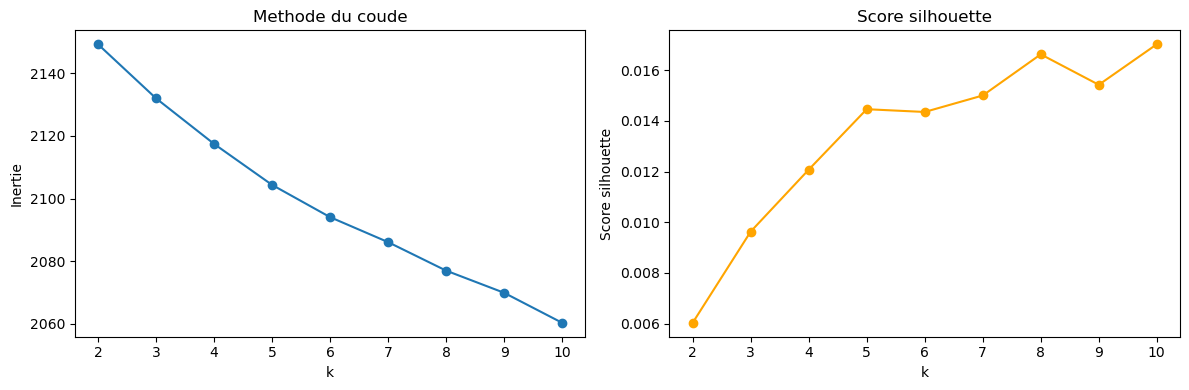

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertie")
axes[0].set_title("Methode du coude")

axes[1].plot(list(k_range), silhouettes, marker="o", color="orange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score silhouette")
axes[1].set_title("Score silhouette")

plt.tight_layout()
plt.show()

On a 5 categories de depart (tech, business, sport, entertainment, politics), on fixe donc k=5 pour comparer directement le clustering aux classes reelles.

On choisit **k = 5** car le jeu de données contient cinq catégories réelles : `tech`, `business`, `sport`, `entertainment` et `politics`.

Ainsi, utiliser cinq clusters permet de comparer directement les groupes créés par KMeans avec ces catégories à l’aide de la matrice de contingence, de l’ARI et du NMI. Ce choix est également cohérent avec les résultats des méthodes du coude et du score de silhouette.

In [7]:
true_k = 5
model = KMeans(n_clusters=true_k, init="k-means++", n_init=10, random_state=42)
df["cluster"] = model.fit_predict(X)
df[["category", "cluster"]].head()

,category,cluster
0,tech,0
1,business,4
2,sport,1
3,sport,1
4,entertainment,2


In [8]:
terms = vectorizer.get_feature_names_out()
order_centroids = model.cluster_centers_.argsort()[:, ::-1]

for i in range(true_k):
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Cluster {i}: {', '.join(top_terms)}")

Cluster 0: people, mobile, technology, users, music, digital, games, phone, software, net
Cluster 1: game, england, win, cup, match, team, players, injury, play, club
Cluster 2: film, best, awards, award, band, festival, music, actor, star, album
Cluster 3: mr, labour, election, blair, party, brown, government, howard, minister, tory
Cluster 4: mr, growth, government, company, economy, market, bank, sales, oil, firm


In [9]:
contingency = pd.crosstab(df["category"], df["cluster"])
contingency

cluster,0,1,2,3,4
category,,,,,
business,7,0,0,3,500
entertainment,5,2,321,0,58
politics,4,1,0,274,138
sport,0,479,2,0,30
tech,363,8,5,0,25


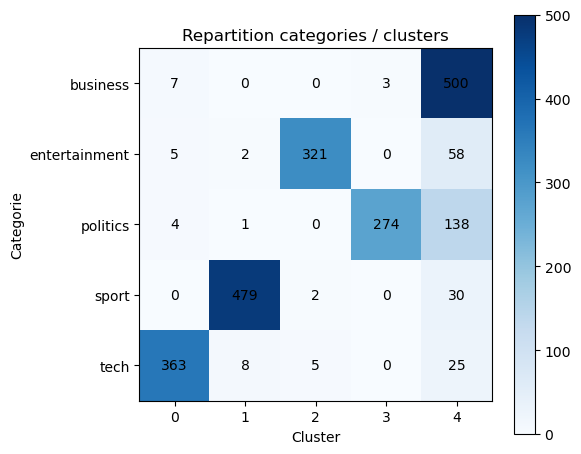

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(contingency.values, cmap="Blues")
ax.set_xticks(range(contingency.shape[1]))
ax.set_xticklabels(contingency.columns)
ax.set_yticks(range(contingency.shape[0]))
ax.set_yticklabels(contingency.index)
ax.set_xlabel("Cluster")
ax.set_ylabel("Categorie")
ax.set_title("Repartition categories / clusters")

for i in range(contingency.shape[0]):
    for j in range(contingency.shape[1]):
        ax.text(j, i, contingency.values[i, j], ha="center", va="center")

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [11]:
ari = adjusted_rand_score(df["category"], df["cluster"])
nmi = normalized_mutual_info_score(df["category"], df["cluster"])
print(f"Adjusted Rand Index : {ari:.3f}")
print(f"Normalized Mutual Information : {nmi:.3f}")

Adjusted Rand Index : 0.695
Normalized Mutual Information : 0.743


**Interpretation**

- Chaque cluster est dominé par une categorie majoritaire, ce qui se retrouve dans les termes les plus frequents de son centroide (vocabulaire clairement lie a un thème : sport, politique, economie, tech, divertissement).
- Les scores ARI et NMI, nettement superieurs a 0, confirment que le clustering non supervise retrouve en grande partie la structure des classes reelles.
- Les erreurs de clustering se concentrent generalement entre categories proches en vocabulaire (ex: business/politics, ou tech/entertainment autour des sujets media), ce qui est coherent avec un chevauchement lexical naturel entre ces themes.

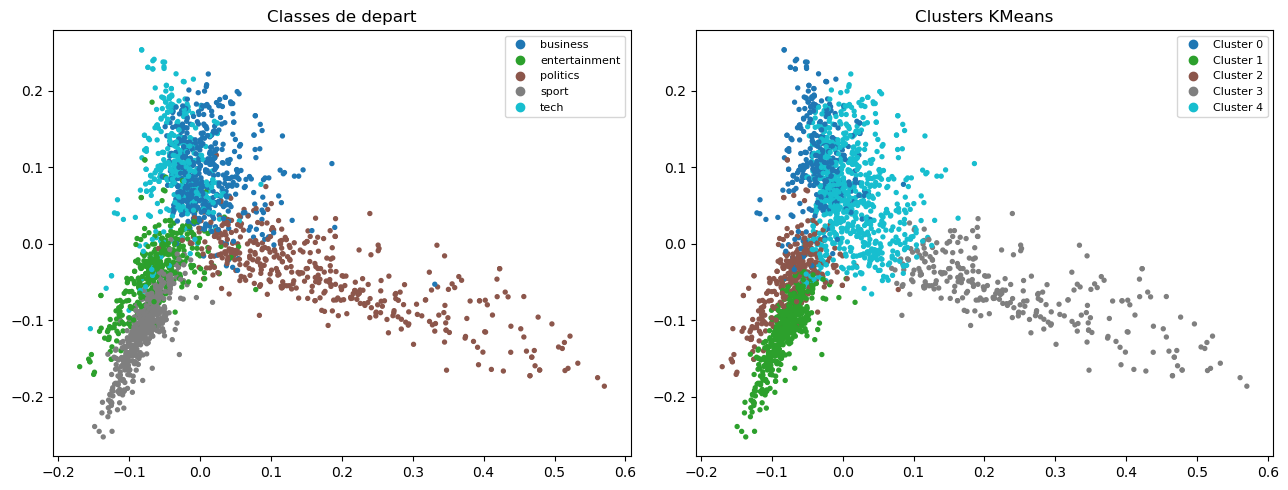

In [12]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X.toarray())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

categories = df["category"].astype("category")
sc0 = axes[0].scatter(coords[:, 0], coords[:, 1], c=categories.cat.codes, cmap="tab10", s=8)
axes[0].set_title("Classes de depart")
axes[0].legend(handles=sc0.legend_elements()[0], labels=list(categories.cat.categories), fontsize=8)

sc1 = axes[1].scatter(coords[:, 0], coords[:, 1], c=df["cluster"], cmap="tab10", s=8)
axes[1].set_title("Clusters KMeans")
axes[1].legend(handles=sc1.legend_elements()[0], labels=[f"Cluster {i}" for i in range(true_k)], fontsize=8)

plt.tight_layout()
plt.show()